In [34]:
# Importing necessary modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = 'Diabetes_prediction.csv'
data = pd.read_csv(file_path)

In [36]:

# Display the first few rows of the dataset
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diagnosis
0,2,115.863387,56.410731,24.336736,94.385783,26.455940,0.272682,20.100494,0
1,2,92.490122,70.615520,23.443591,138.652426,23.910167,0.665160,44.912281,0
2,1,88.141469,63.262618,23.404364,149.358082,21.948250,0.676022,48.247873,1
3,2,108.453101,67.793632,20.751580,108.751638,24.209304,0.289636,42.749868,0
4,1,127.849443,94.725685,22.603078,25.269987,32.997477,0.601315,32.797789,0


Looking at these charts, we can see Diagnosis 0 is more common - it's about 70% of cases. Diagnosis 1 is less common, only about 30%. This uneven split might cause problems if we're trying to analyze or predict things. We might need special methods to deal with this imbalance.

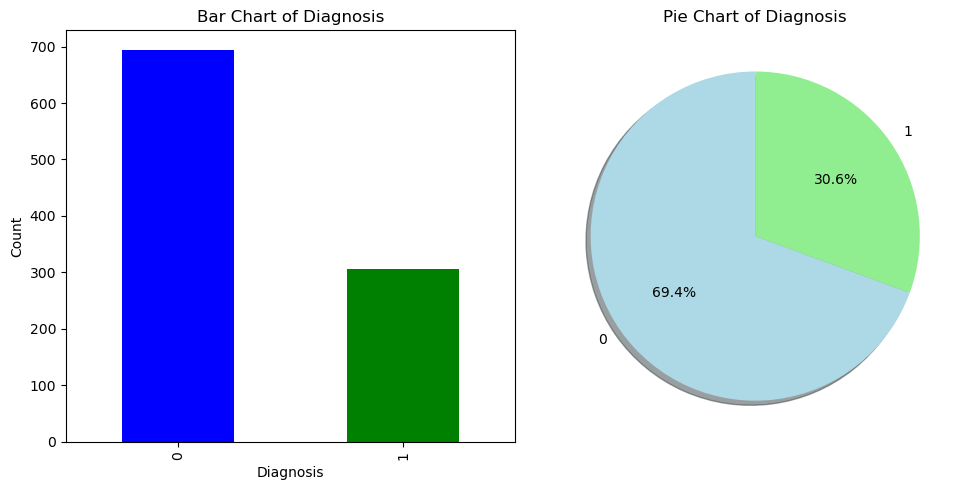

In [39]:

# Step 1: Bar chart and Pie chart
# Feature selection: We'll use 'Glucose', 'Age', and 'Diagnosis'

# Bar chart for 'Diagnosis'
diagnosis_counts = data['Diagnosis'].value_counts()


# Pie chart for 'Diagnosis'
plt.figure(figsize=(10, 5))

# Bar chart for Diagnosis
plt.subplot(1, 2, 1)
diagnosis_counts.plot(kind='bar', color=['blue', 'green'])
plt.title('Bar Chart of Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Count')

# Pie chart for Diagnosis
plt.subplot(1, 2, 2)
diagnosis_counts.plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'lightgreen'], startangle=90, shadow=True)
plt.title('Pie Chart of Diagnosis')
plt.ylabel('')  # Hide y-label

plt.tight_layout()
plt.show()

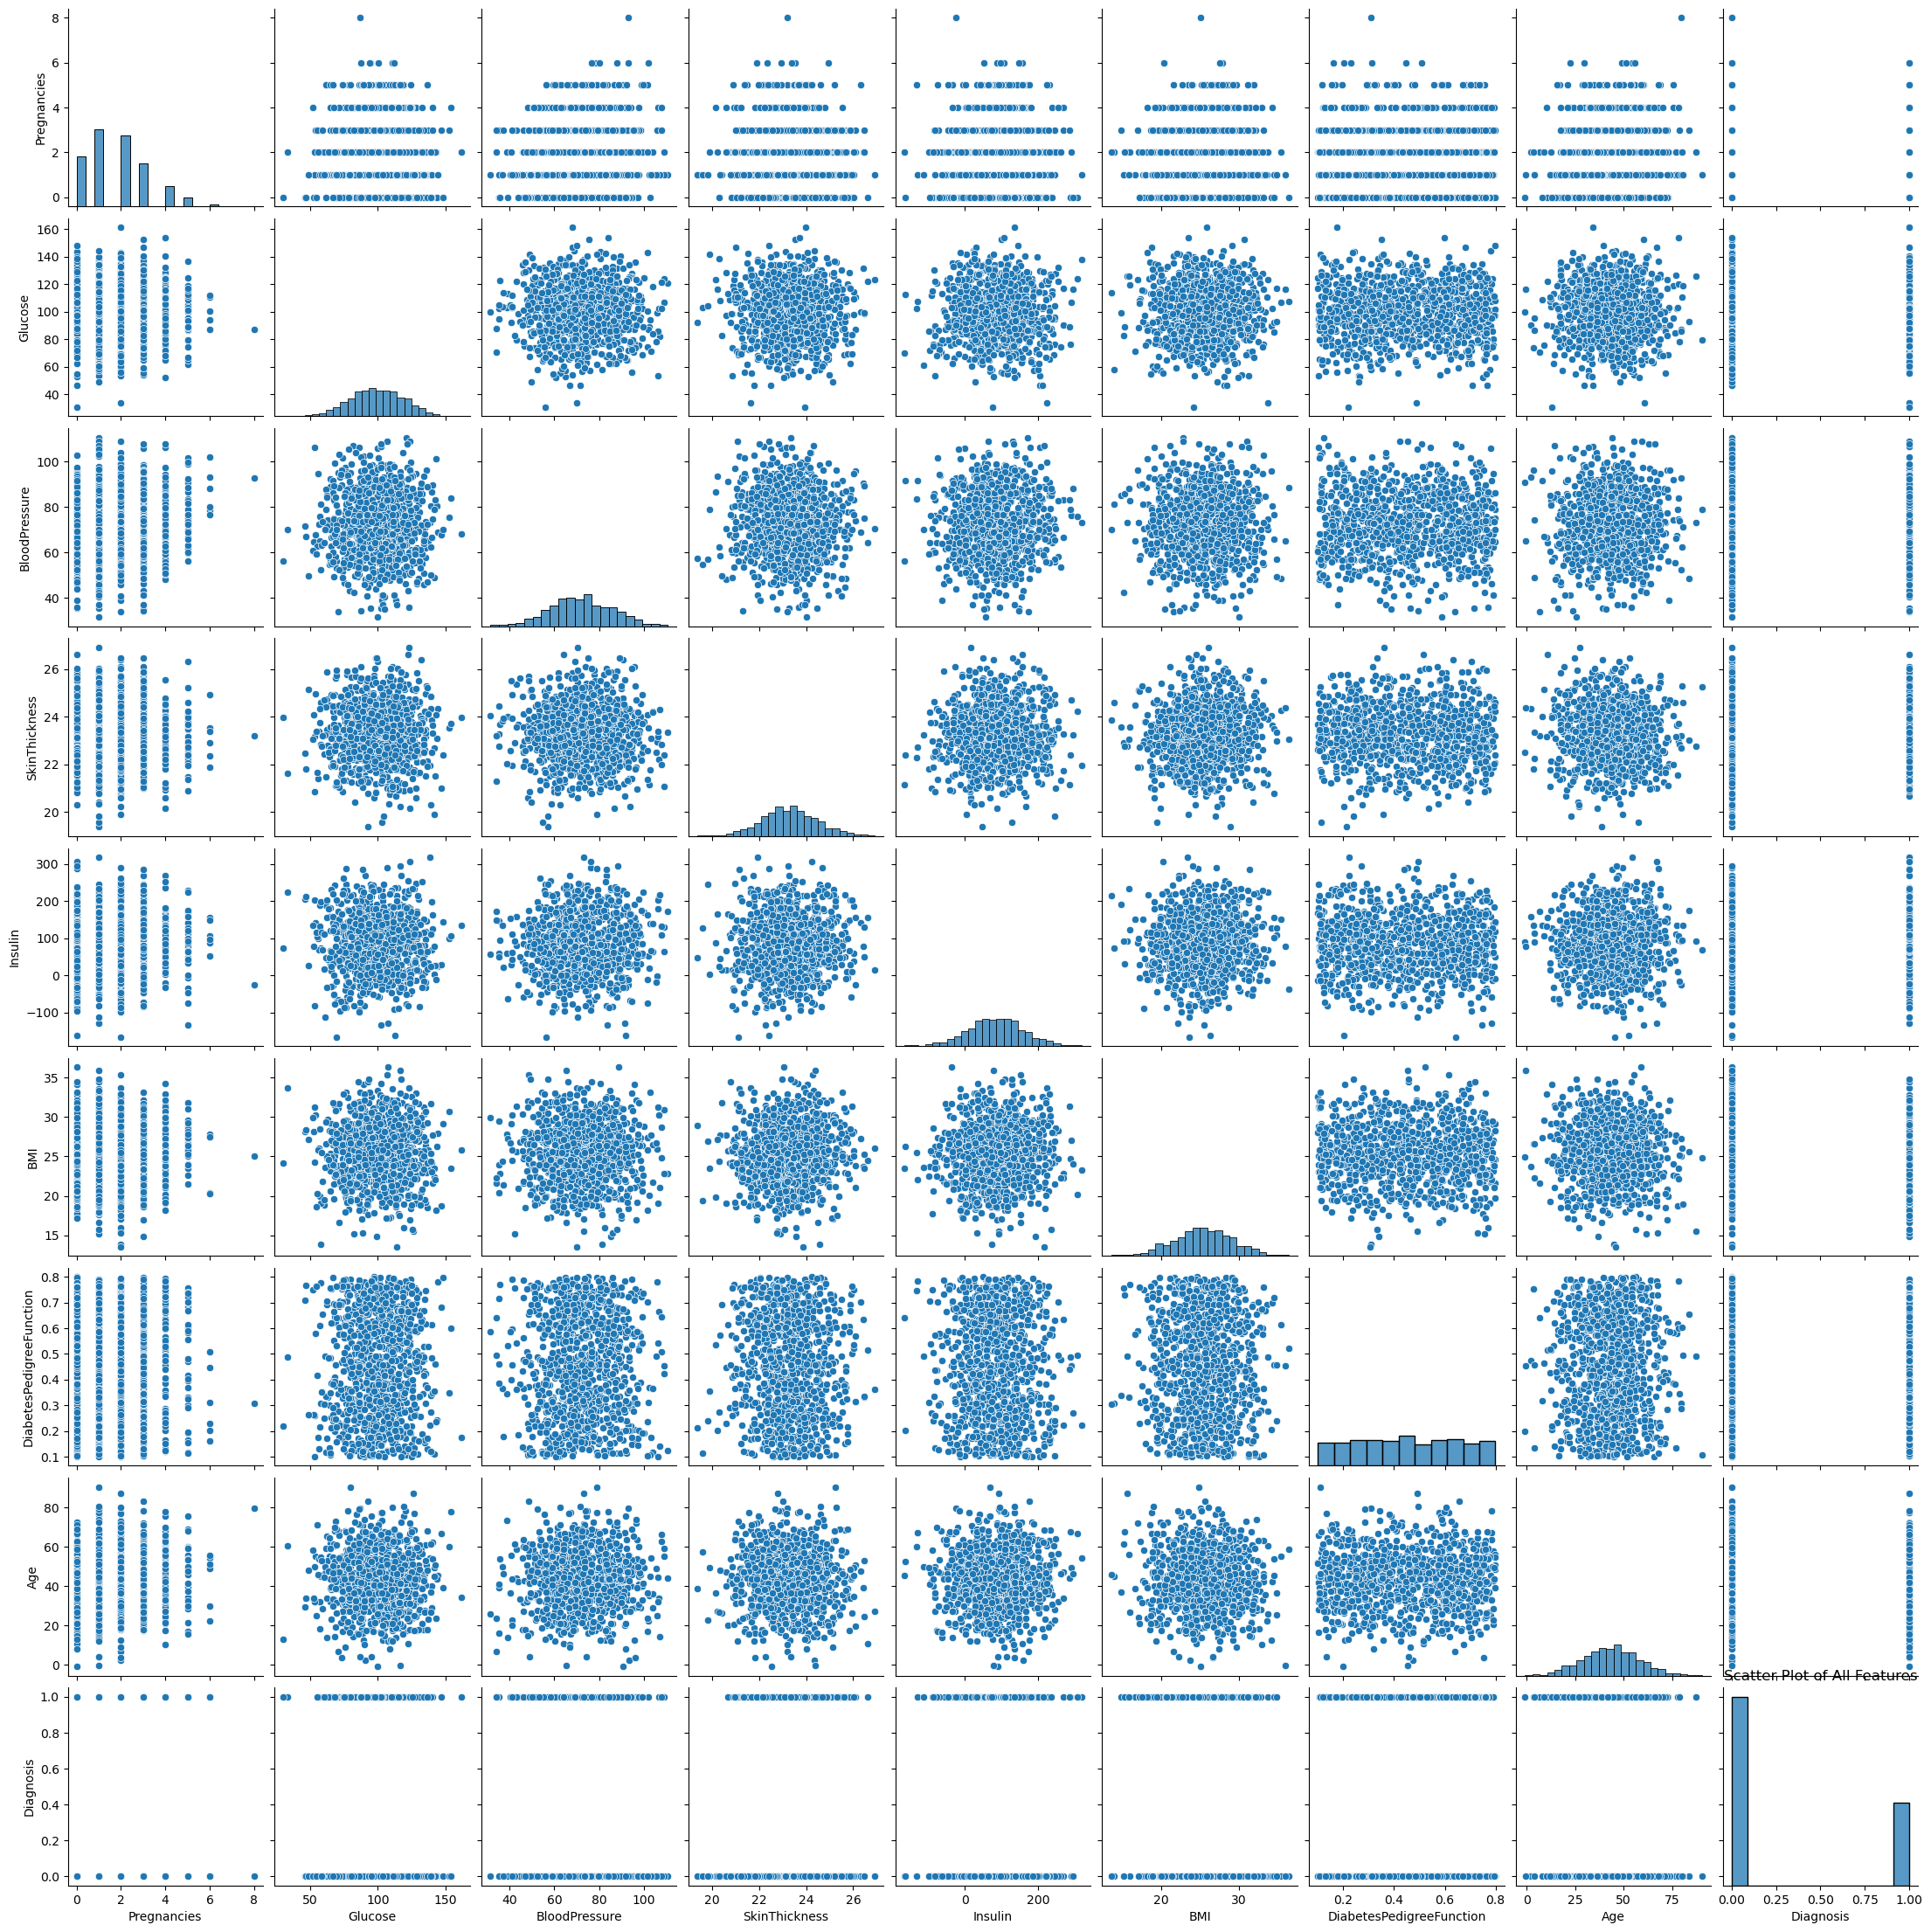

In [41]:
# Step 2: Scatter plot of all features
sns.pairplot(data)
plt.title("Scatter Plot of All Features")
plt.show()

The scatter plot matrix displays the pairwise relationships between all numerical features, helping to identify correlations or trends between features

In [43]:
from sklearn.preprocessing import MinMaxScaler

# Selecting numerical columns for normalization
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns

# Applying Min-Max normalization
scaler = MinMaxScaler()
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])

# Display the normalized data
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diagnosis
0,0.250,0.652740,0.315287,0.658051,0.537659,0.566704,0.246771,0.230251,0.0
1,0.250,0.473865,0.494364,0.539717,0.629306,0.454928,0.807760,0.501259,0.0
2,0.125,0.440584,0.401667,0.534520,0.651471,0.368788,0.823286,0.537693,1.0
3,0.250,0.596029,0.458789,0.183049,0.567402,0.468062,0.271005,0.477640,0.0
4,0.125,0.744470,0.798316,0.428356,0.394566,0.853918,0.716504,0.368938,0.0


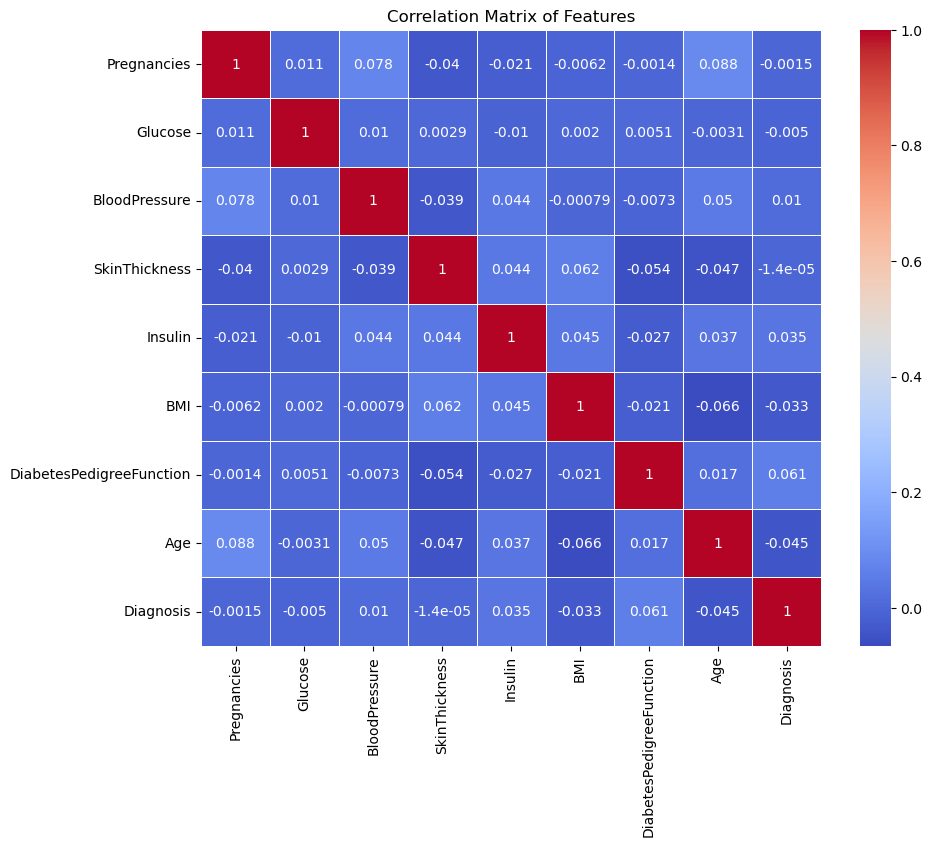

In [44]:
# Step 3: Correlation matrix and selecting features based on correlation
correlation_matrix = data.corr()

# Visualizing the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix of Features")
plt.show()

In [45]:
# Let's select features with high correlation to the target 'Diagnosis'
high_correlation_features = correlation_matrix['Diagnosis'][abs(correlation_matrix['Diagnosis']) > 0.035]
high_correlation_features

Insulin                     0.035411
DiabetesPedigreeFunction    0.060549
Age                        -0.044726
Diagnosis                   1.000000
Name: Diagnosis, dtype: float64

These are the features with the highest Correlation. So it could be a good idea to select them.

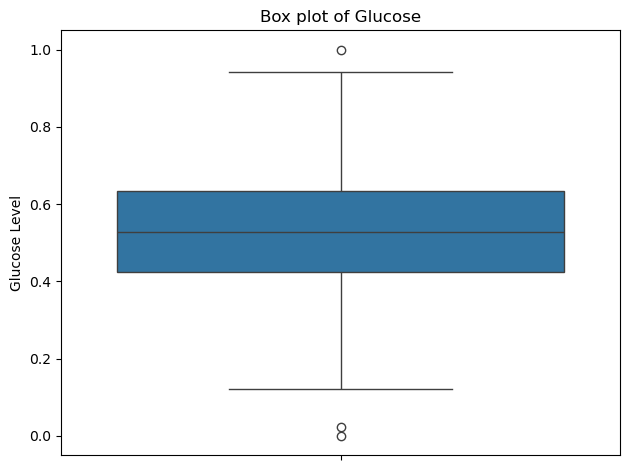

In [70]:
#BOX PLOT OF GLUCOSE
sns.boxplot(y='Glucose', data=data)
plt.title('Box plot of Glucose')
plt.ylabel('Glucose Level')
plt.tight_layout()
plt.show()

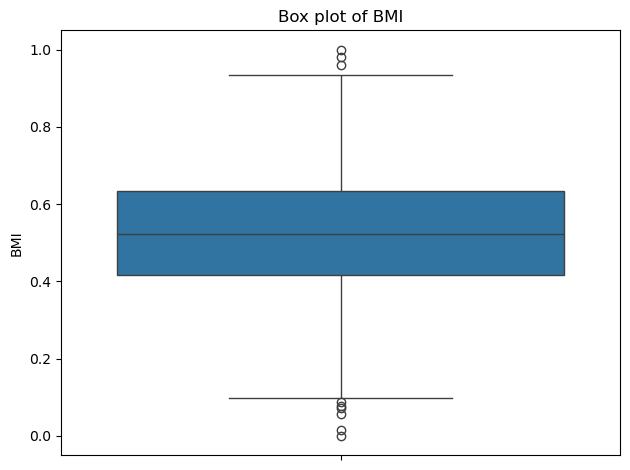

In [72]:
#BOX PLOT FOR BMI
sns.boxplot(y='BMI', data=data)
plt.title('Box plot of BMI')
plt.ylabel('BMI')
plt.tight_layout()
plt.show()

HISTOGRAM FOR TWO FEATURES

Text(0, 0.5, 'Frequency')

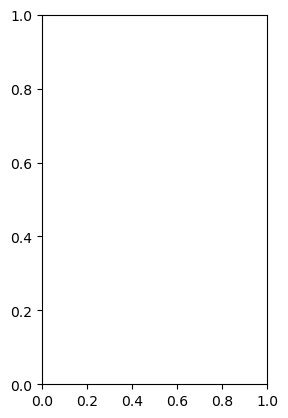

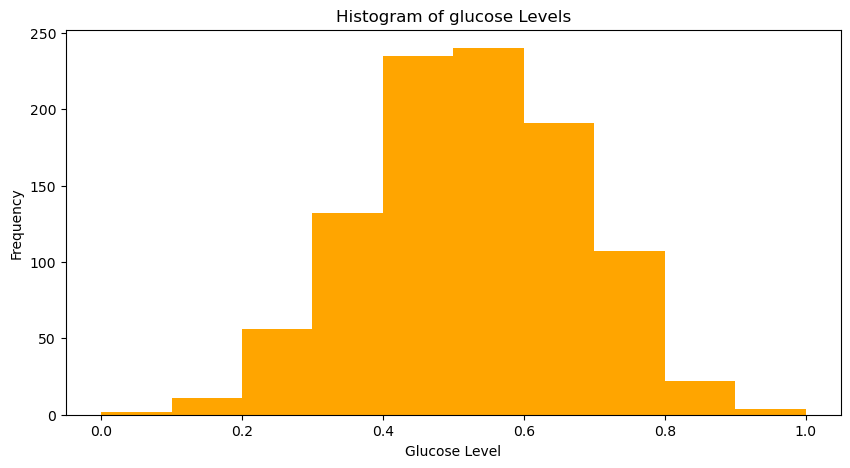

In [64]:
# Histogram for glucose
plt.subplot(1,2,1)
plt.figure(figsize = (10,5))
plt.hist(data['Glucose'],bins = 10 ,color = 'orange')
plt.title('Histogram of glucose Levels')
plt.xlabel('Glucose Level')
plt.ylabel('Frequency')

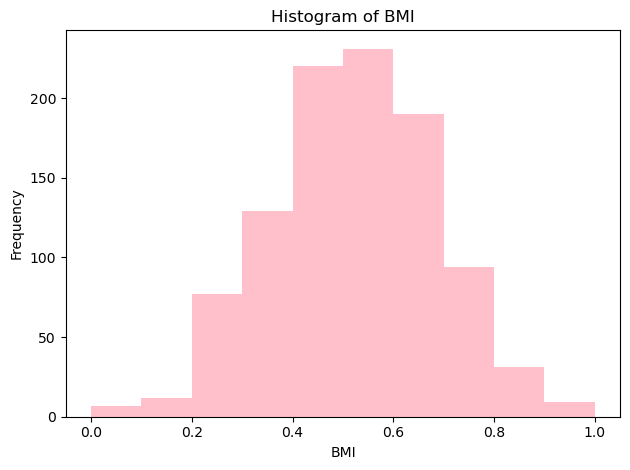

In [62]:
#HISTOGRAM of BMI
plt.hist(data['BMI'],bins = 10 ,color = 'pink')
plt.title('Histogram of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')

plt.tight_layout()